In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from nsppk import NSPPK

from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator, edge_neighbors


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 1000
min_num_nodes = 14
max_num_nodes = 16
USE_TARGETS = False

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
targets = [max(dict(graph.degree()).values(), default=0) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
if USE_TARGETS:
    print("target: max_degree")
else:
    print("targets disabled")


dataset: zinc_250k
n_graphs: 1000
node_range: [14, 16]
targets disabled


In [4]:
vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)

feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(connected_component(), unlabel(), merge(use_edges=True), filter_by_edge_label(must_have_one_of=['aromatic']), edge()), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=2, distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

target_estimator = None
if USE_TARGETS:
    target_estimator = GraphEstimator(
        transformer=NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True),
        estimator=RandomForestRegressor(
            random_state=0,
            n_estimators=300,
            n_jobs=-1,
        ),
    )

generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=graph_estimator,
    target_estimator=target_estimator,
    target_estimator_mode="regression",
    decomposition_function=add(cycle(), tree()),
    enforce_diversity=False,
    n_negative_per_positive=5,
    n_replicates=5,
    beam_size=2,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    verbose=True,
    seed=0,
)


In [5]:
%%time
generator.store(graphs, targets=targets)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


stored_graphs = 1000
CPU times: user 24 s, sys: 923 ms, total: 24.9 s
Wall time: 29.1 s


## Repair Workflow

Select one stored molecule at random, perturb it by moving `k` edges at random,
then repair it with `EdgeGenerator.repair(...)` using the nearest stored
neighbors as the local fitting set.

graph_idx = 554
repair_target = None
k_edge_moves = 4
original_edges = 14
perturbed_edges = 14


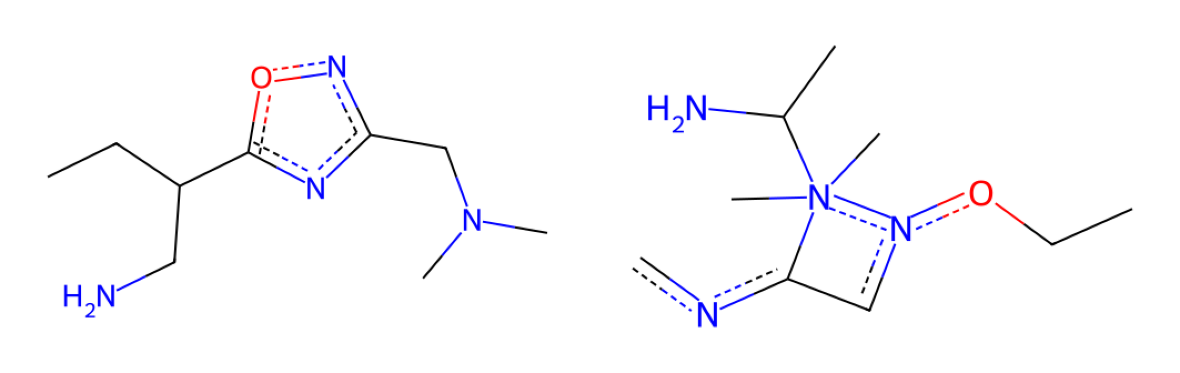

In [6]:
idx = random.randrange(len(graphs))
graph = graphs[idx]
repair_target = targets[idx] if USE_TARGETS else None

k = 4
perturb_seed = 0


def move_random_edges(graph, k, *, seed=0):
    perturbed = graph.copy()
    rng = random.Random(seed)
    for _ in range(max(0, int(k))):
        neighbors = edge_neighbors(
            perturbed,
            n_samples=1,
            seed=rng.randrange(10**9),
        )
        if not neighbors:
            break
        perturbed = neighbors[0]
    return perturbed


perturbed_graph = move_random_edges(graph, k, seed=perturb_seed)

print(f"graph_idx = {idx}")
print(f"repair_target = {repair_target}")
print(f"k_edge_moves = {k}")
print(f"original_edges = {graph.number_of_edges()}")
print(f"perturbed_edges = {perturbed_graph.number_of_edges()}")
_ = display_graphs([graph, perturbed_graph], n_graphs_per_line=2)

[repair] query_index=None n_neighbors=7 neighbor_indices=[665, 375, 591, 261, 506, 416, 198] neighbor_distances=[71.8818, 72.3118, 73.437, 73.5867, 73.9797, 74.0338, 74.29]


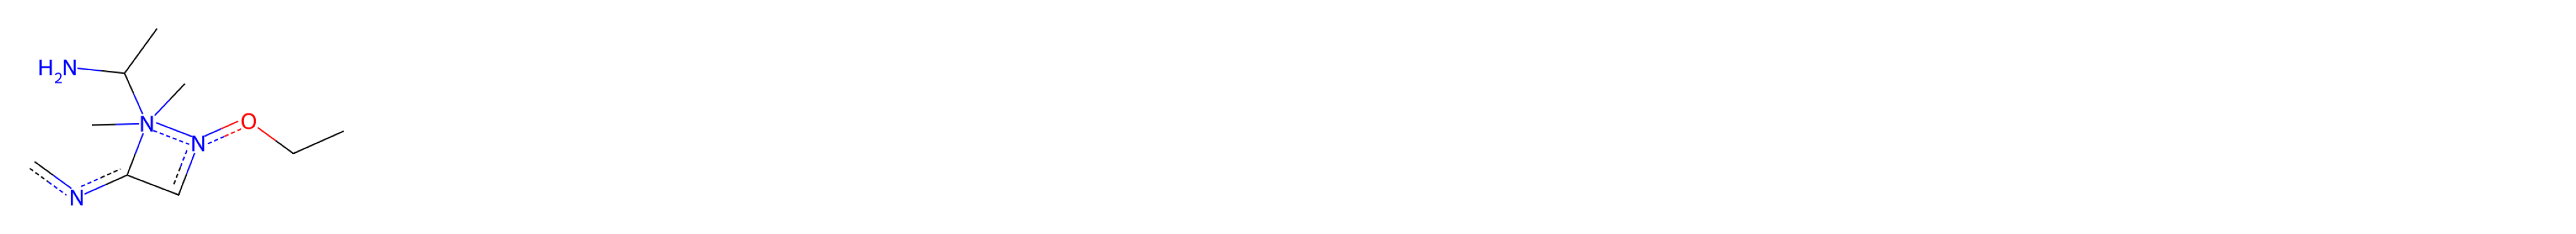

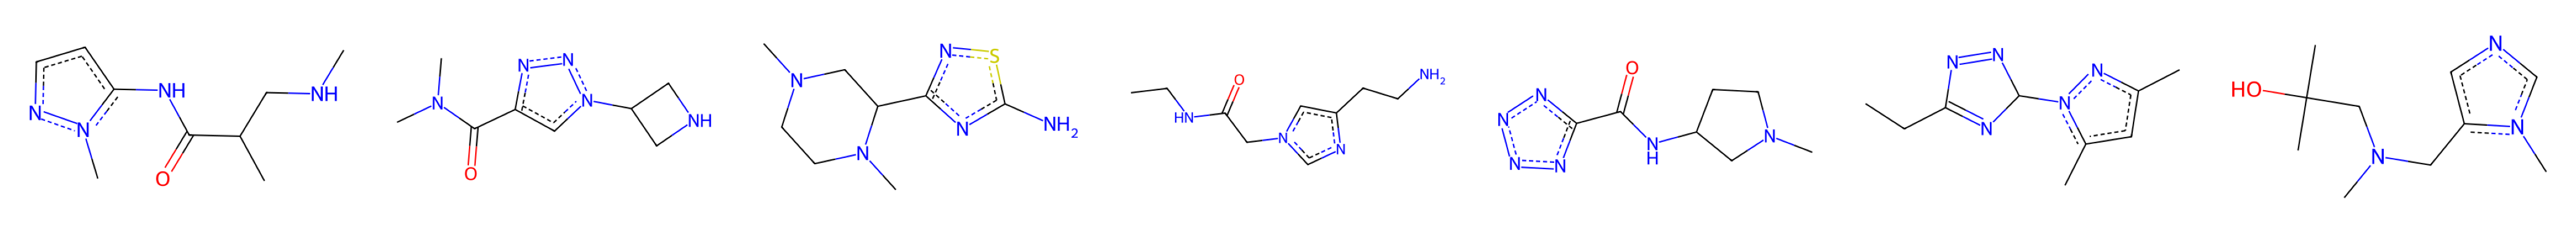

[fit] partial_feasibility_graphs=483 final_feasibility_graphs=7 positives=510 negatives=2375 dataset=2885 partial_time=0m 17.3s final_time=0m 0.8s
[fit] graph_estimator_graphs=2885 positive_labels=510 negative_labels=2375 time=0m 56.1s
[repair] attempt=1/2 start_edges=10 target_edges=14 removed_edges=[(9, 12), (8, 9), (12, 13), (3, 9)]


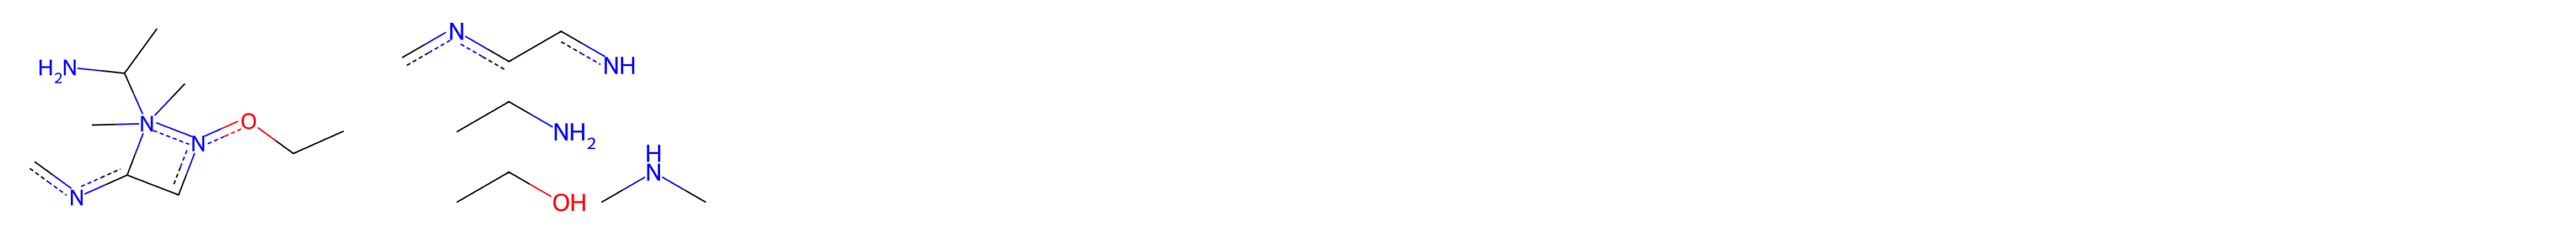

[graph 0] start start_edges=10 target_edges=14 remaining_edges=4


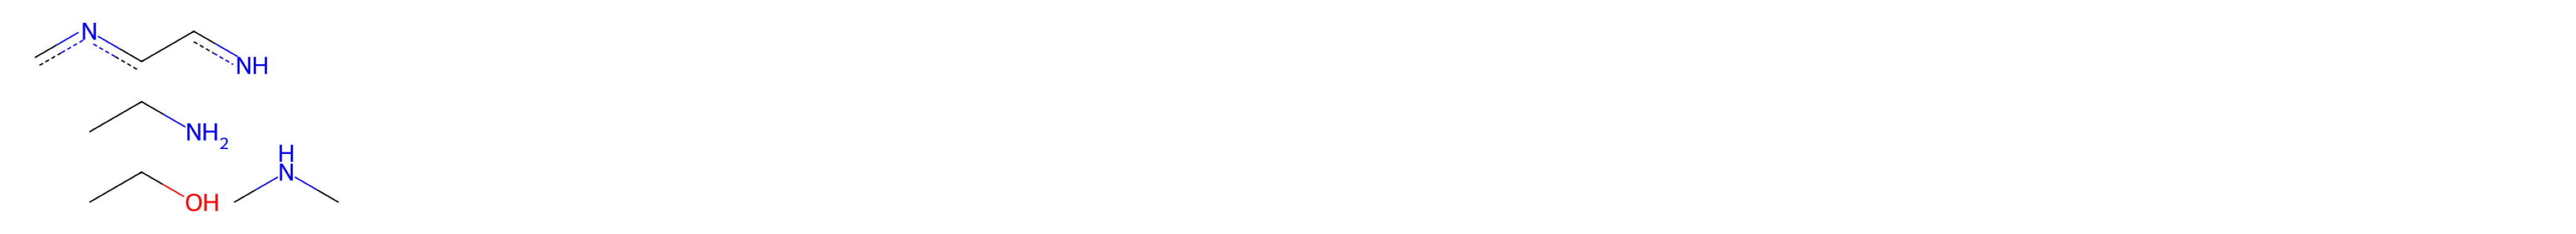

[graph 0] fallback=1/3 beam_limit=2
[graph 0] fallback=1/3 depth=1 remaining_edges=3 step_time=24m 22.8s eta=73m 8.3s
generated=243 partial_feasible=64 viable=64 retained=2 tried=243 partial_infeasible=179 terminal_completion_unknown=64
best_score=0.081
beam_limit=2


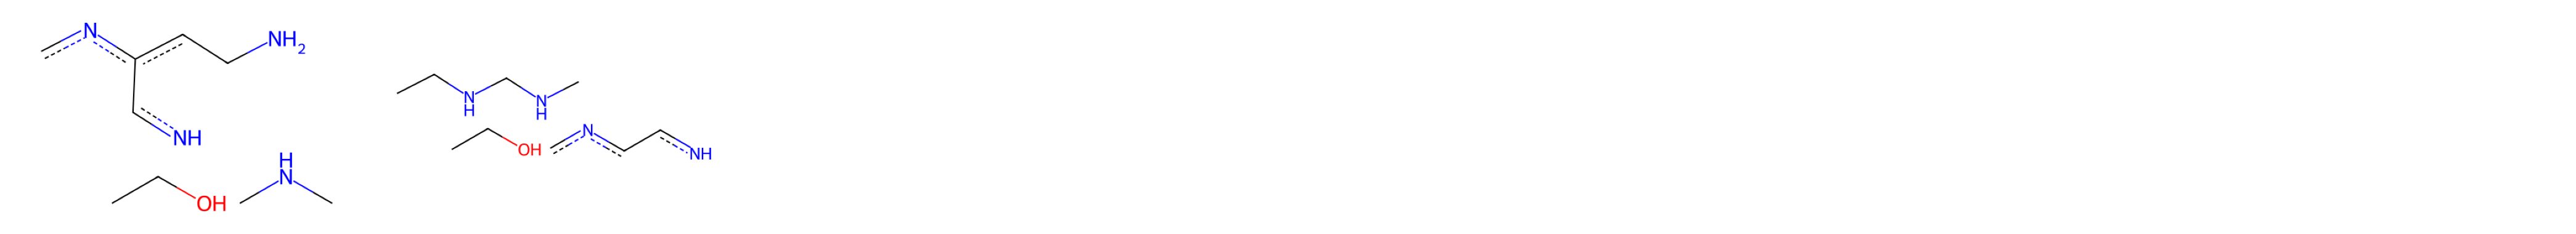

CPU times: user 22min 23s, sys: 42.3 s, total: 23min 6s
Wall time: 29min 18s


KeyboardInterrupt: 

In [7]:
%%time
n_neighbors = 7
repair_path = generator.repair(
    perturbed_graph,
    n_neighbors=n_neighbors,
    target=repair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=7, **kwargs),
)

print(f"repair_path_length = {len(repair_path)}")
if len(repair_path) > 0:
    print(f"final_n_edges = {repair_path[-1].number_of_edges()}")
    display_graphs(repair_path, n_graphs_per_line=7)
    print('Original and perturbed graphs:')
    display_graphs([graph, perturbed_graph], n_graphs_per_line=2)
    print('Repaired graph:')
    display_graphs([repair_path[-1]], n_graphs_per_line=1)
    print('Repair training set:')
    display_graphs(generator.last_repair_training_graphs_, n_graphs_per_line=7)


---